## startup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from cycler import cycler

df = pd.read_csv('../data/processed/game_processed.csv')

In [2]:
print(f"La dimension de nuestro dataframe es: {df.shape}")
df.columns

La dimension de nuestro dataframe es: (60475, 27)


Index(['game_year', 'fgm_home', 'fga_home', 'fg3m_home', 'fg3a_home',
       'pts_home', 'fgm_away', 'fga_away', 'fg3m_away', 'fg3a_away',
       'pts_away', 'season_type', 'total_puntos', 'ganador', 'fg3m', 'fg3a',
       'fga', 'fgm', 'fg3pc', 'fgpc', 'fg3pc_away', 'fg3pc_home',
       '3p%_ganador', '3p%_perdedor', 'fg2a', 'fg2m', 'fg2pc'],
      dtype='str')

In [3]:
df.describe()

,game_year,fgm_home,fga_home,fg3m_home,fg3a_home,pts_home,fgm_away,fga_away,fg3m_away,fg3a_away,...,fgm,fg3pc,fgpc,fg3pc_away,fg3pc_home,3p%_ganador,3p%_perdedor,fg2a,fg2m,fg2pc
count,60475.000000,60475.000000,60475.000000,60475.000000,60475.000000,60475.000000,60475.000000,60475.000000,60475.000000,60475.000000,...,60475.000000,60475.000000,60475.000000,60475.000000,60475.000000,60475.000000,60475.000000,60475.000000,60475.000000,60475.000000
mean,1995.005837,39.443224,64.788987,4.719091,13.203456,104.220802,38.123787,64.604977,4.628342,13.228640,...,77.567011,0.257052,0.354882,0.257710,0.251217,0.230410,0.278517,102.961869,68.219578,0.377459
std,19.607245,6.694533,35.993872,4.687975,11.874653,14.701784,6.408377,35.888015,4.600634,11.816551,...,11.426572,0.173770,0.196314,0.200239,0.194594,0.178951,0.211667,59.481518,14.202566,0.209896
min,1946.000000,0.000000,0.000000,0.000000,0.000000,18.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-11.000000,0.000000,0.000000
25%,1984.000000,35.000000,69.000000,0.000000,0.000000,95.000000,34.000000,68.000000,0.000000,0.000000,...,70.000000,0.000000,0.379747,0.000000,0.000000,0.000000,0.000000,96.000000,58.000000,0.394958
50%,1998.000000,39.000000,80.000000,4.000000,12.000000,104.000000,38.000000,80.000000,4.000000,12.000000,...,78.000000,0.309524,0.443787,0.294118,0.285714,0.260870,0.333333,123.000000,66.000000,0.469231
75%,2010.000000,44.000000,87.000000,8.000000,21.000000,114.000000,42.000000,87.000000,7.000000,21.000000,...,85.000000,0.384615,0.479042,0.400000,0.393939,0.360000,0.428571,141.000000,78.000000,0.510753
max,2023.000000,72.000000,240.000000,28.000000,70.000000,175.000000,68.000000,129.000000,29.000000,63.000000,...,136.000000,1.000000,0.702970,1.000000,1.000000,1.000000,1.000000,339.000000,134.000000,0.733333


## first graph

In [4]:
df_ys = df.groupby('game_year')['total_puntos'].mean()

df_ys.head()

game_year
1946    129.507812
1947    140.691525
1948    151.726644
1949    160.364211
1950    161.536346
Name: total_puntos, dtype: float64

<Axes: title={'center': 'NBA: Promedio de puntos por año'}, xlabel='game_year'>

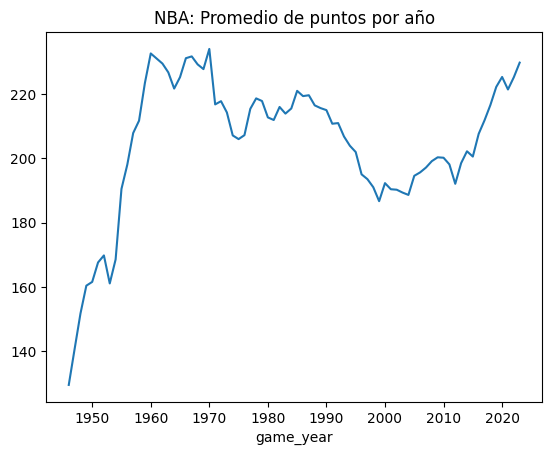

In [ ]:
df_ys.plot(title="NBA: Promedio de puntos por año")

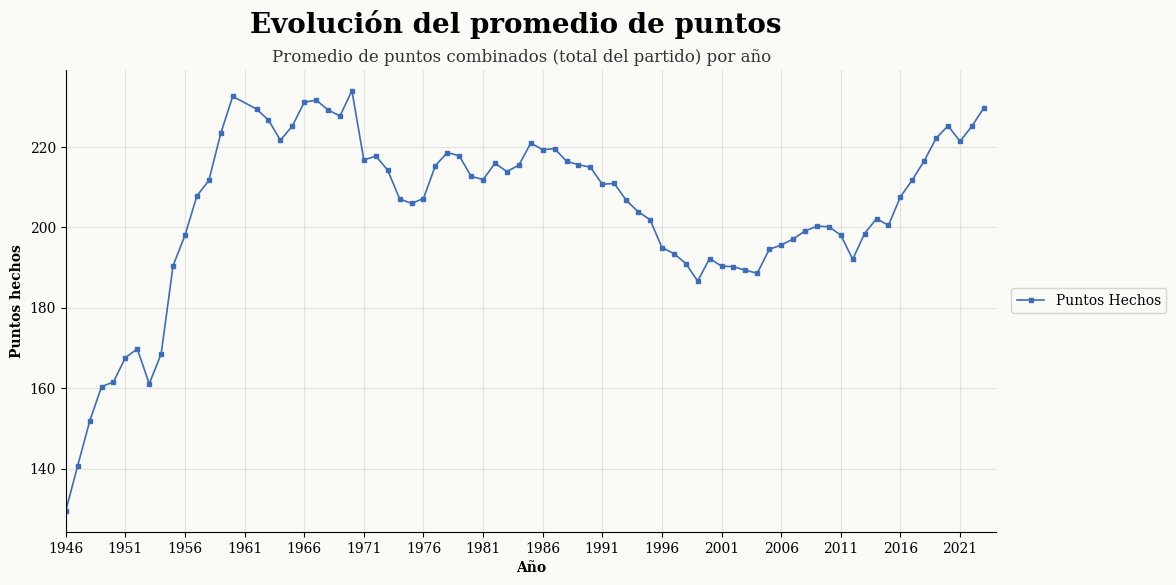

In [94]:
with plt.rc_context({
    "figure.facecolor": "#fafbf6",
    "axes.facecolor": "#fafbf6",
    "figure.figsize": (12, 6),
    "font.family": "serif",
    "grid.alpha": 0.3,
    "lines.linewidth": 1.2,
    "lines.markersize": 3,
    "axes.titlecolor": "#333333"
}):
    ax = plt.gca()
    plt.plot(df_ys, label='Puntos Hechos', marker='s', color='#3d6db9')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xlabel('Año', fontweight='bold')
    ax.set_ylabel('Puntos hechos', fontweight='bold')
    plt.legend(loc='center', bbox_to_anchor=(1.1,0.5))
    plt.suptitle("Evolución del promedio de puntos", fontsize=20, fontweight='bold', ha='center', x=0.5)
    plt.title("Promedio de puntos combinados (total del partido) por año", fontsize=12, ha='center',x=0.49)
    plt.grid(True)
    plt.xticks(np.arange(1946, 2024, 5))
    plt.xlim(1946,2024)
    plt.savefig('../outputs/ptp_prom.jpeg', dpi=300, bbox_inches='tight')
    plt.show()


## second graph

In [30]:
df_taw = df.groupby('game_year')['fg3a'].mean()
df_tmw = df.groupby('game_year')['fg3m'].mean()


<Axes: title={'center': 'NBA: Promedio de triples intentados por partido'}, xlabel='game_year'>

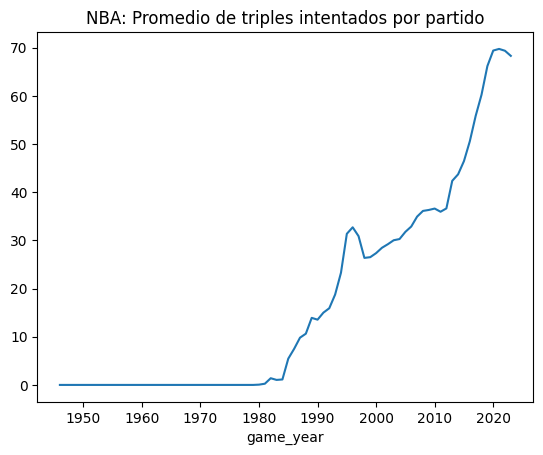

In [ ]:
df_taw.plot(title="NBA: Promedio de triples intentados por partido")

<Axes: title={'center': 'NBA: Triples hechos por partido'}, xlabel='game_year'>

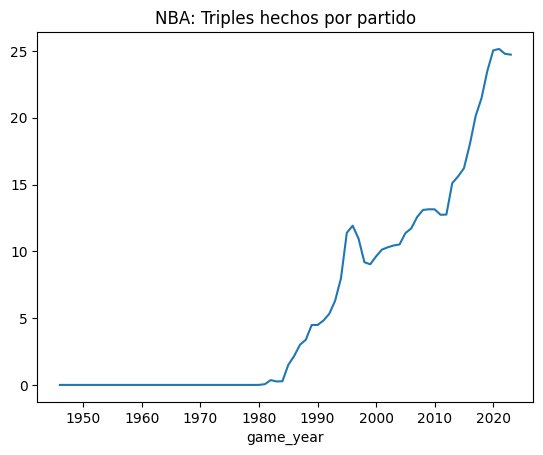

In [22]:
df_tmw.plot(title="NBA: Triples hechos por partido")

In [96]:
df_3mix = pd.DataFrame({
    'Triples Hechos': df_tmw,
    'Triples Intentados': df_taw
})

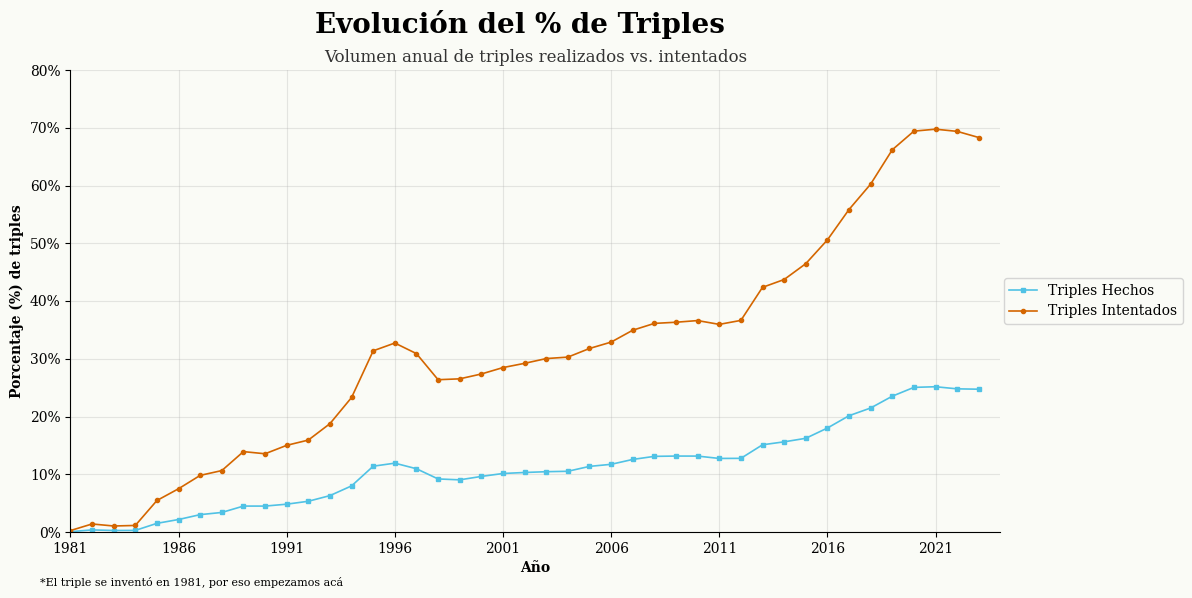

In [102]:
with plt.rc_context({
    "figure.facecolor": "#fafbf6",
    "axes.facecolor": "#fafbf6",
    "figure.figsize": (12, 6),
    "font.family": "serif",
    "grid.alpha": 0.3,
    "lines.linewidth": 1.2,
    "lines.markersize": 3,
    "axes.titlecolor": "#333333"
}):
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xlabel('Año', fontweight='bold')
    ax.set_ylabel('Porcentaje (%) de triples', fontweight='bold')
    plt.plot(df_3mix.index, df_3mix['Triples Hechos'], label='Triples Hechos', marker='s', color='#50c2e5')
    plt.plot(df_3mix.index, df_3mix['Triples Intentados'], label='Triples Intentados', marker='o', color='#d46600')
    plt.legend(loc='center', bbox_to_anchor=(1.1,0.5))
    plt.grid(True)
    plt.suptitle("Evolución del % de Triples", x=0.5, fontsize=20, fontweight='bold')
    plt.title("Volumen anual de triples realizados vs. intentados", x=0.5, fontsize=12)
    plt.gcf().text(0.1,0.02,"*El triple se inventó en 1981, por eso empezamos acá", fontsize=8, fontweight='ultralight')
    plt.xticks(np.arange(1981, 2024, 5))
    plt.xlim(1981,2024)
    plt.yticks(plt.gca().get_yticks(), [f'{int(x)}%' for x in plt.gca().get_yticks()])
    plt.ylim(0,80)
    plt.savefig('../outputs/triple_evolucion.jpeg', dpi=300, bbox_inches='tight')
    plt.show()

In [64]:
df_ganador = df.groupby('game_year')['3p%_ganador'].mean()
df_perdedor = df.groupby('game_year')['3p%_perdedor'].mean()

In [99]:
df_comp = pd.DataFrame({
    'Triples Ganadores': df_ganador,
    'Triples Perdedor': df_perdedor
})
df_comp = df_comp * 100

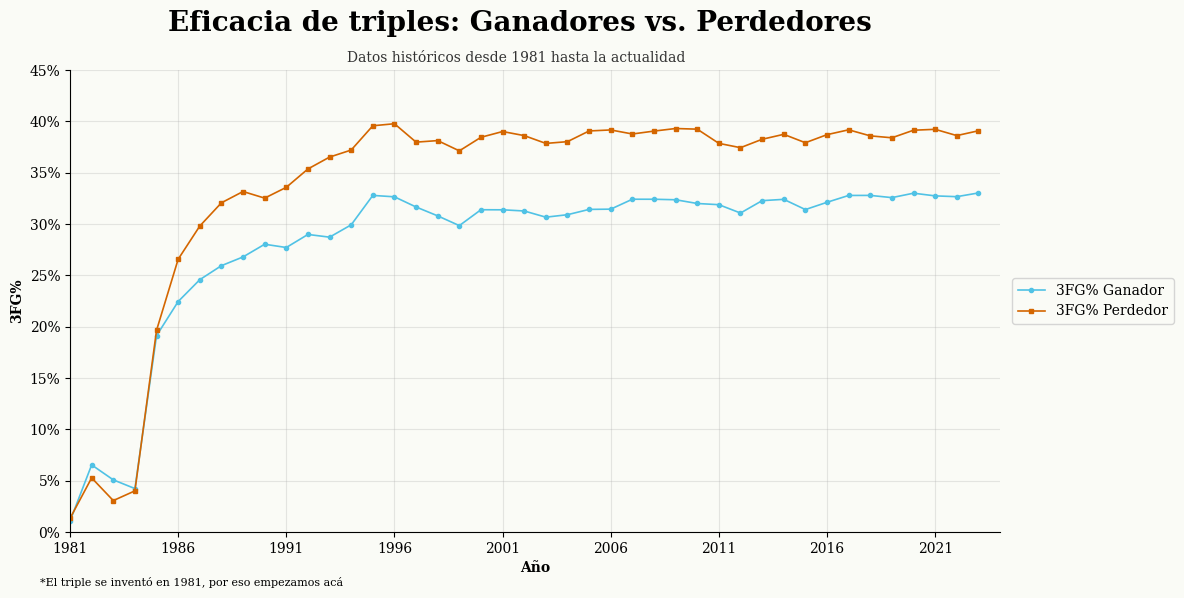

In [109]:
with plt.rc_context({
    "figure.facecolor": "#fafbf6",
    "axes.facecolor": "#fafbf6",
    "figure.figsize": (12, 6),
    "font.family": "serif",
    "grid.alpha": 0.3,
    "lines.linewidth": 1.2,
    "lines.markersize": 3,
    "axes.titlecolor": "#333333"
}):
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xlabel('Año', fontweight='bold')
    ax.set_ylabel('3FG%', fontweight='bold')
    plt.plot(df_comp.index, df_comp['Triples Ganadores'], label='3FG% Ganador', marker='o', color='#50c2e5')
    plt.plot(df_comp.index, df_comp['Triples Perdedor'], label='3FG% Perdedor', marker='s', color='#d46600')
    plt.legend(loc='center', bbox_to_anchor=(1.1,0.5))
    plt.xticks(np.arange(1981,2024,5))
    plt.xlim(1981,2024)
    plt.yticks(plt.gca().get_yticks(), [f'{int(x)}%' for x in plt.gca().get_yticks()])
    plt.ylim(0,45)
    plt.suptitle("Eficacia de triples: Ganadores vs. Perdedores", x=0.5, fontsize=20, fontweight='bold')
    plt.title("Datos históricos desde 1981 hasta la actualidad",x=0.48, fontsize=10)
    plt.gcf().text(0.1,0.02,"*El triple se inventó en 1981, por eso empezamos acá", fontsize=8, fontweight='ultralight')
    plt.grid(True)
    plt.savefig('../outputs/triple_win_loser.jpeg', dpi=300, bbox_inches='tight')
    plt.show()

## third graph

In [74]:
df_fg2a = df.groupby('game_year')['fg2a'].mean()
df_fg2m = df.groupby('game_year')['fg2m'].mean()
df_fg2pc = df.groupby('game_year')['fg2pc'].mean()
df_triple = df.groupby('game_year')['fg3pc'].mean()

In [75]:
df_mida = pd.DataFrame({
    'Triples Intentados': df_taw,
    'Mid intentado': df_fg2a
})
df_mida.head(50)

,Triples Intentados,Mid intentado
game_year,,
1946,0.000000,13.726562
1947,0.000000,13.762712
1948,0.000000,8.525952
1949,0.000000,0.324211
1950,0.000000,1.387033
1951,0.000000,12.975069
1952,0.000000,17.950413
1953,0.000000,14.586111
1954,0.000000,17.881620


<Axes: title={'center': 'NBA: Triples intentados vs Tiros de media intentados'}, xlabel='game_year'>

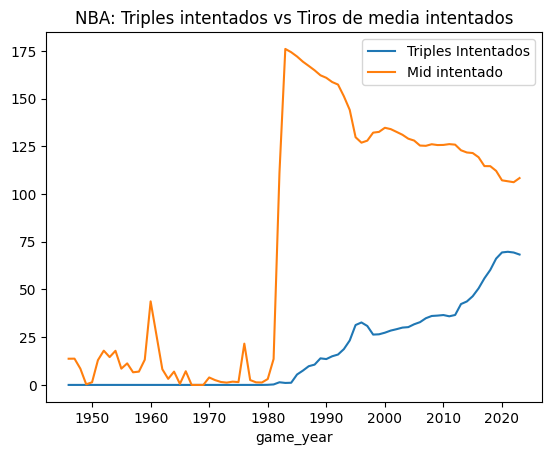

In [ ]:
df_mida.plot(title="NBA: Triples intentados vs Tiros de media intentados")

In [87]:
df_midpc = pd.DataFrame({
    '% Triples': df_triple,
    '% Tiros de 2': df_fg2pc
})
df_midpc.dropna(subset=['% Triples', '% Tiros de 2'], inplace=True)
df_midpc = df_midpc * 100
df_midpc.head()

,% Triples,% Tiros de 2
game_year,,
1946,0.0,1.983299
1947,0.0,1.909803
1948,0.0,1.261993
1949,0.0,0.068353
1950,0.0,0.285701


In [88]:
df_midpc.plot(title="NBA: Comparación de % triples vs % tiros de media")

<Axes: title={'center': 'NBA: Comparación de % triples vs % tiros de media'}, xlabel='game_year'>

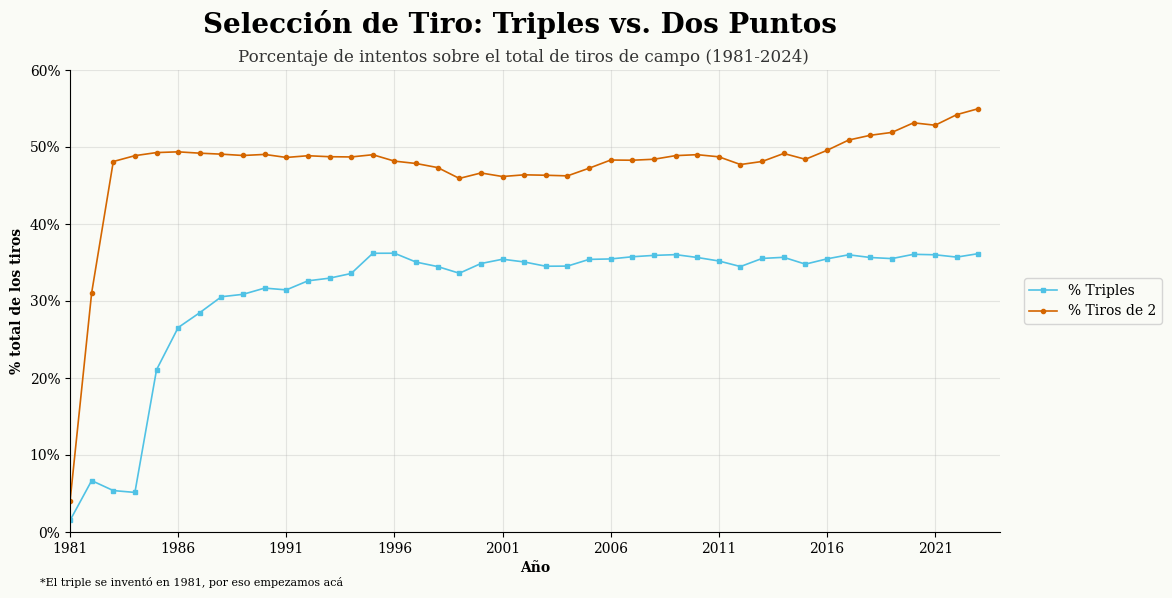

In [110]:
with plt.rc_context({
    "figure.facecolor": "#fafbf6",
    "axes.facecolor": "#fafbf6",
    "figure.figsize": (12, 6),
    "font.family": "serif",
    "grid.alpha": 0.3,
    "lines.linewidth": 1.2,
    "lines.markersize": 3,
    "axes.titlecolor": "#333333"
}):
    ax = plt.gca()
    ax.plot(df_midpc.index, df_midpc['% Triples'], label='% Triples', marker='s', color='#50c2e5')
    ax.plot(df_midpc.index, df_midpc['% Tiros de 2'], label='% Tiros de 2', marker='o', color='#d46600')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xlabel('Año', fontweight='bold')
    ax.set_ylabel('% total de los tiros', fontweight='bold')
    plt.legend(loc='center', bbox_to_anchor=(1.1,0.5))
    plt.xticks(np.arange(1981,2024,5))
    plt.xlim(1981, 2024)
    plt.yticks(plt.gca().get_yticks(), [f'{int(x)}%' for x in plt.gca().get_yticks()])
    plt.ylim(0,60)
    plt.suptitle("Selección de Tiro: Triples vs. Dos Puntos", x=0.5, fontsize=20, fontweight='bold')
    plt.title("Porcentaje de intentos sobre el total de tiros de campo (1981-2024)",x=0.487, fontsize=12)
    plt.gcf().text(0.1,0.02,"*El triple se inventó en 1981, por eso empezamos acá", fontsize=8, fontweight='ultralight')
    plt.grid(True)
    plt.savefig('../outputs/triple_mid.jpeg', dpi=300, bbox_inches='tight')
    plt.show()